### **DATA ANALYSIS PYTHON PROJECT - BLINKIT ANALYSIS**

### **Business Problem**

The objective of this project is to analyze Blinkit sales data to identify trends in product categories, outlet performance, outlet sizes, and customer preferences using Python-based data analysis and visualization techniques.

#### **Import Libraries**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


#### **Import Raw Data**

In [4]:
df = pd.read_csv('blinkit_data.csv')

#### **Sample Data**

In [5]:
df.head(15)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0
5,low fat,FDS52,Frozen Foods,2020,OUT017,Tier 2,Small,Supermarket Type1,0.005505,8.89,102.4016,5.0
6,Low Fat,NCU05,Health and Hygiene,2011,OUT010,Tier 3,Small,Grocery Store,0.098312,11.80,81.4618,5.0
7,Low Fat,NCD30,Household,2015,OUT045,Tier 2,Small,Supermarket Type1,0.026904,19.70,96.0726,5.0
8,Low Fat,FDW20,Fruits and Vegetables,2000,OUT013,Tier 3,High,Supermarket Type1,0.024129,20.75,124.1730,5.0
9,Low Fat,FDX25,Canned,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.101562,NaN,181.9292,5.0


In [6]:
df.tail()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
8518,low fat,NCT53,Health and Hygiene,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0
8519,low fat,FDN09,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0
8520,low fat,DRE13,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0
8521,reg,FDT50,Dairy,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0
8522,reg,FDM58,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,112.2544,4.0


#### **Size of Data**

In [7]:
print('Size of the dataset:', df.shape)

Size of the dataset: (8523, 12)


#### **Field info**

In [8]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='str')

#### **Data Types**

In [9]:
df.dtypes

Item Fat Content                 str
Item Identifier                  str
Item Type                        str
Outlet Establishment Year      int64
Outlet Identifier                str
Outlet Location Type             str
Outlet Size                      str
Outlet Type                      str
Item Visibility              float64
Item Weight                  float64
Sales                        float64
Rating                       float64
dtype: object

#### **Data Cleaning**

In [10]:
print(list(df['Item Fat Content'].unique()))

['Regular', 'Low Fat', 'low fat', 'LF', 'reg']


In [11]:
df['Item Fat Content'] = df['Item Fat Content'].replace({'LF':'Low Fat',
                                                         'low fat':'Low Fat',
                                                         'reg':'Regular'})

In [12]:
print(list(df['Item Fat Content'].unique()))

['Regular', 'Low Fat']


##### **Exploratory Data Analysis**

In [13]:
df.describe().round(2)

,Outlet Establishment Year,Item Visibility,Item Weight,Sales,Rating
count,8523.00,8523.00,7060.00,8523.00,8523.00
mean,2010.83,0.07,12.86,140.99,3.97
std,8.37,0.05,4.64,62.28,0.61
min,1998.00,0.00,4.56,31.29,1.00
25%,2000.00,0.03,8.77,93.83,4.00
50%,2012.00,0.05,12.60,143.01,4.00
75%,2017.00,0.09,16.85,185.64,4.20
max,2022.00,0.33,21.35,266.89,5.00


In [14]:
df.isnull().sum()

Item Fat Content                0
Item Identifier                 0
Item Type                       0
Outlet Establishment Year       0
Outlet Identifier               0
Outlet Location Type            0
Outlet Size                     0
Outlet Type                     0
Item Visibility                 0
Item Weight                  1463
Sales                           0
Rating                          0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

#### **Correlation Heatmap**

<Axes: >

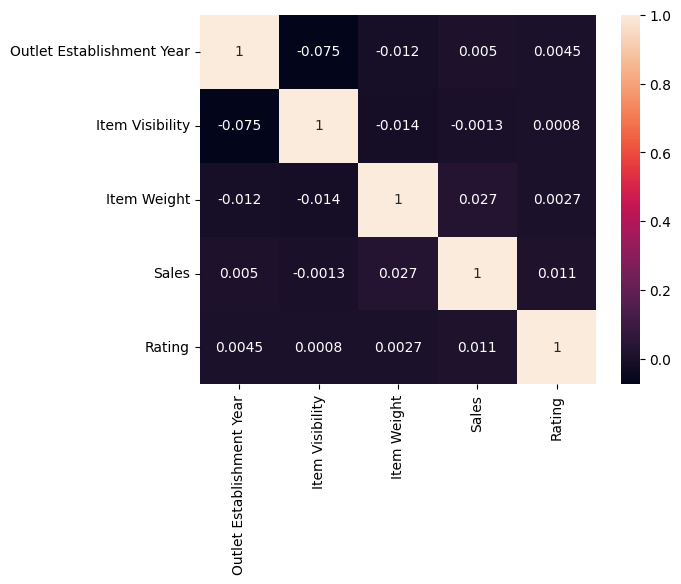

In [16]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

#### **Business Requirements**

#### **KPI's Requirements**

In [17]:
# Total Sales
total_sales = df['Sales'].sum()

# Average Sales
average_sales = df['Sales'].mean()

# No_of_items_sold
no_of_records = df['Sales'].count()

# Average_Rating
average_rating = df['Rating'].mean()

# Display
print(f"Total Sales: ${total_sales:,.0f}")
print(f"Average Sales: ${average_sales:,.1f}")
print(f"No. of items sold: {no_of_records:,.0f}")
print(f"Average Rating : {average_rating:,.1f}")

Total Sales: $1,201,681
Average Sales: $141.0
No. of items sold: 8,523
Average Rating : 4.0


#### **CHARTS REQUIREMENTS**

##### **Total Sales by Fat Content**

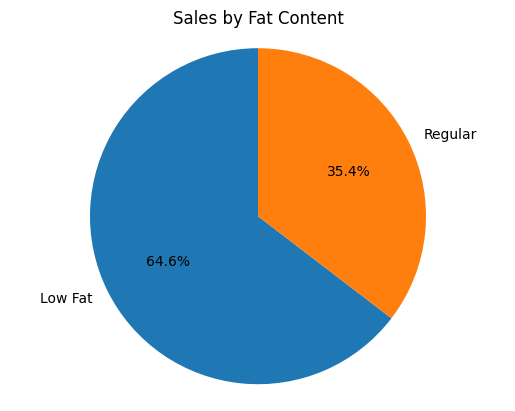

In [18]:
sales_by_fat = df.groupby('Item Fat Content')['Sales'].sum()
plt.pie(sales_by_fat, labels = sales_by_fat.index,
        autopct = '%.1f%%',
        startangle = 90)
plt.title('Sales by Fat Content')
plt.axis('equal')
plt.show()

###### **Insight: Low Fat products contribute the majority of total sales (64.6%) compared to Regular fat products (35.4%), indicating higher customer preference and stronger sales performance for Low Fat items.**

##### **Total Sales by Item Type**

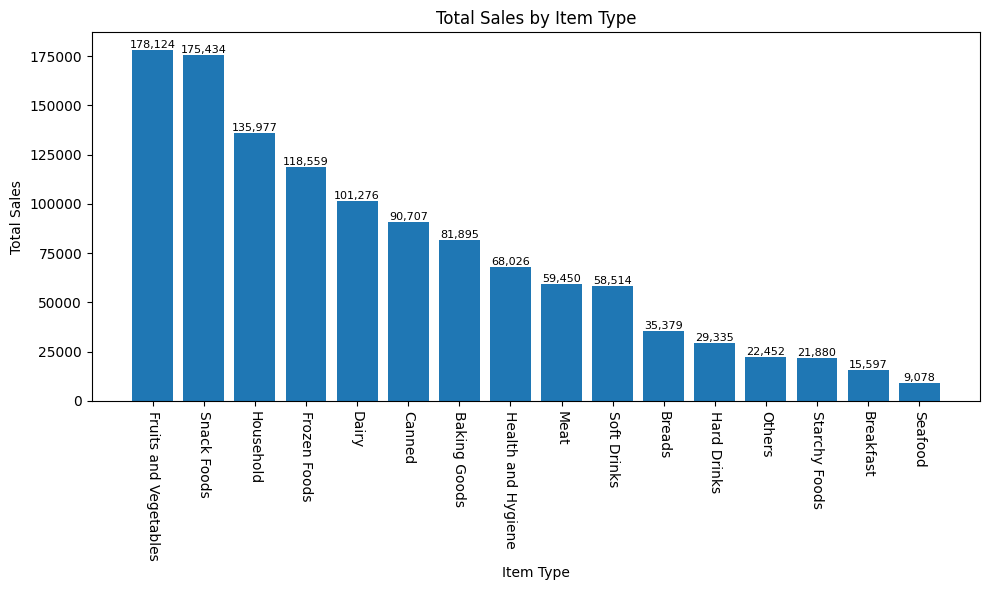

In [19]:
sales_by_type = df.groupby('Item Type')['Sales'].sum().sort_values(ascending = False)

plt.figure(figsize=(10,6))
bars= plt.bar(sales_by_type.index, sales_by_type.values)

plt.xticks(rotation = -90)
plt.xlabel('Item Type')
plt.ylabel('Total Sales')
plt.title('Total Sales by Item Type')

for bar in bars:
    plt.text(bar.get_x()+ bar.get_width()/2, bar.get_height(),
             f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

###### **Insight: Fruits & Vegetables and Snack Foods generated the highest total sales, while Seafood and Breakfast contributed the least. This indicates stronger customer demand for daily-consumption and convenience food categories.**

##### **Fat Content by Outlet for Total Sales**

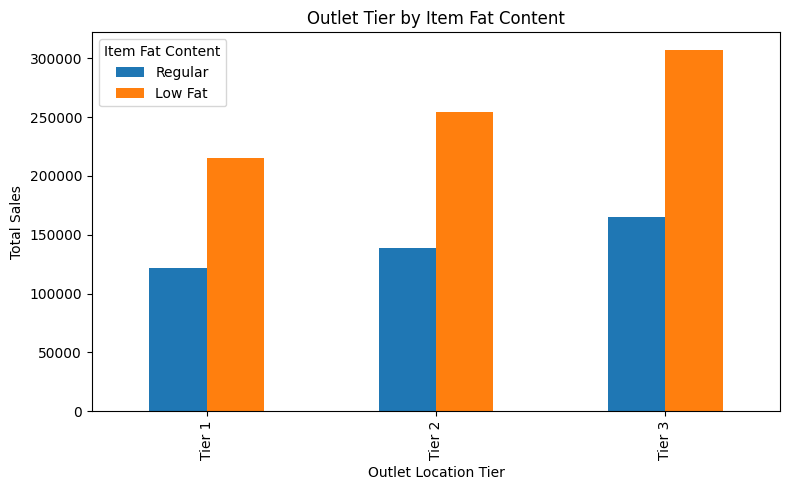

In [20]:
grouped = df.groupby(['Outlet Location Type', 'Item Fat Content'])['Sales'].sum().unstack()
grouped = grouped[['Regular','Low Fat']]

ax = grouped.plot(kind = 'bar', figsize=(8,5), title = 'Outlet Tier by Item Fat Content')
plt.xlabel('Outlet Location Tier') 
plt.ylabel('Total Sales')
plt.legend(title = 'Item Fat Content')
plt.tight_layout()
plt.show()

###### **Insight: Across all outlet tiers, Low Fat products consistently generated higher sales than Regular products. Tier 3 outlets recorded the highest overall sales, indicating stronger customer demand and sales performance in Tier 3 locations.**

##### **Total Sales by Outlet Establishment**

#####

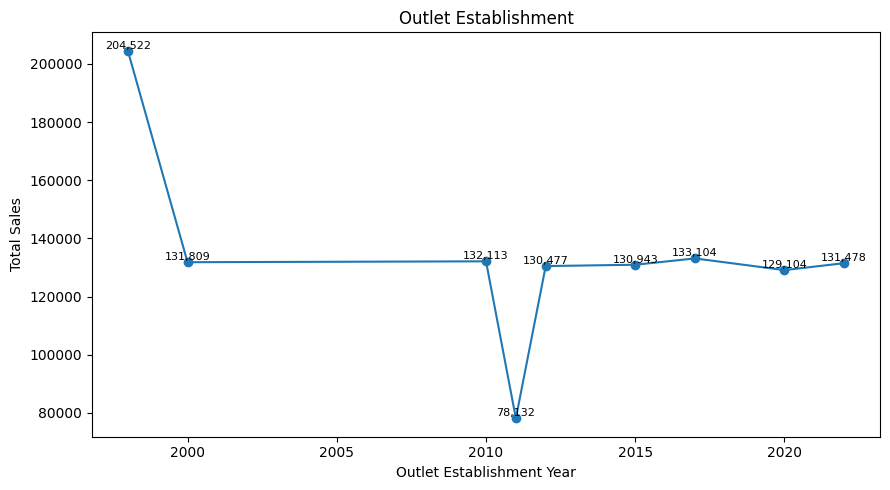

In [21]:
sales_by_year = df.groupby('Outlet Establishment Year')['Sales'].sum().sort_index()

plt.figure(figsize=(9,5))
plt.plot(sales_by_year.index, sales_by_year.values, marker = 'o', linestyle ='-')

plt.xlabel('Outlet Establishment Year')
plt.ylabel('Total Sales')
plt.title('Outlet Establishment')

for x,y in zip(sales_by_year.index, sales_by_year.values):
    plt.text(x,y, f'{y:,.0f}', ha= 'center', va = 'bottom', fontsize = 8)

plt.tight_layout()
plt.show()

###### **Insight: Outlet sales remained relatively stable across most establishment years, with a significant peak in 1998 and a noticeable decline in 2011. This suggests older outlets, especially those established in 1998, contributed the highest sales performance.**

##### **Sales by Outlet Size**

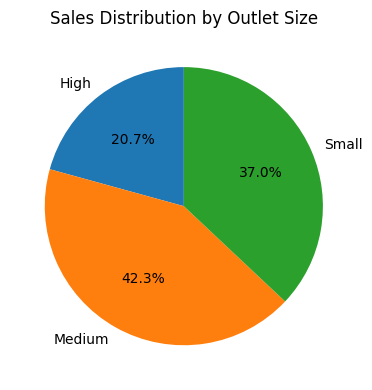

In [22]:
sales_by_size = df.groupby('Outlet Size')['Sales'].sum()

plt.figure(figsize=(4,4))
plt.pie(sales_by_size, labels= sales_by_size.index, autopct='%1.1f%%', startangle=90)

plt.title('Sales Distribution by Outlet Size')
plt.tight_layout()
plt.show()

###### **Insight: Medium-sized outlets contributed the highest share of total sales (42.3%), followed by Small outlets (37.0%), while High-sized outlets generated the lowest sales share (20.7%).**

##### **Sales by Outlet Location**

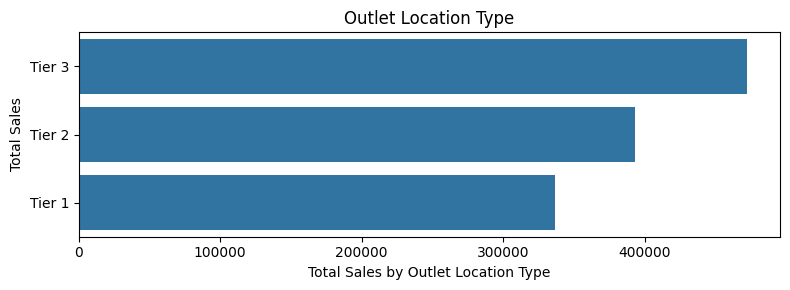

In [23]:
sales_by_location = df.groupby('Outlet Location Type')['Sales'].sum().reset_index()
sales_by_location = sales_by_location.sort_values('Sales', ascending=False)

plt.figure(figsize=(8,3))
ax = sns.barplot(x='Sales', y= 'Outlet Location Type', data = sales_by_location)

plt.xlabel('Total Sales by Outlet Location Type')
plt.ylabel('Total Sales')
plt.title('Outlet Location Type')

plt.tight_layout()
plt.show()

###### **Insight: Tier 3 outlet locations generated the highest total sales, followed by Tier 2, while Tier 1 recorded the lowest sales. This indicates stronger sales performance in Tier 3 locations.**

#### Conclusion

This analysis identified key sales patterns across outlet types, outlet sizes, item categories, and fat content using Python, Pandas, Matplotlib, and Seaborn. 

The findings revealed that:
- Low Fat products generated significantly higher sales than Regular products.
- Tier 3 outlets and Medium-sized stores achieved the strongest sales performance.
- Fruits & Vegetables and Snack Foods were the top-performing product categories.
- Most numeric features showed weak linear correlation, indicating sales are influenced by multiple business factors rather than a single variable.

Overall, this project demonstrates practical skills in data cleaning, exploratory data analysis (EDA), data visualization, and business insight generation using Python.